## Synapses and Weights in Spiking Neural Networks (SNNs)


### 🧠 What is a Synapse?

A synapse is the connection between two neurons.

Neuron A  ────(synapse)────>  Neuron B

Neuron A = pre-synaptic neuron

Neuron B = post-synaptic neuron

When neuron A fires a spike, the signal passes through the synapse and affects neuron B.

This models the biological Synapse in the brain.

## ⚡ What is Synaptic Weight?

Each synapse has a weight (strength).

Weight Value	Effect
Large weight	Strong influence
Small weight	Weak influence
Negative weight	Inhibition

Example:

Neuron A spike → weight = 0.8 → Neuron B voltage increases
Neuron A spike → weight = -0.5 → Neuron B voltage decreases

So weights control how strongly neurons influence each other

Vpost​=Vpost​+w

## 🔬 Types of Synapses

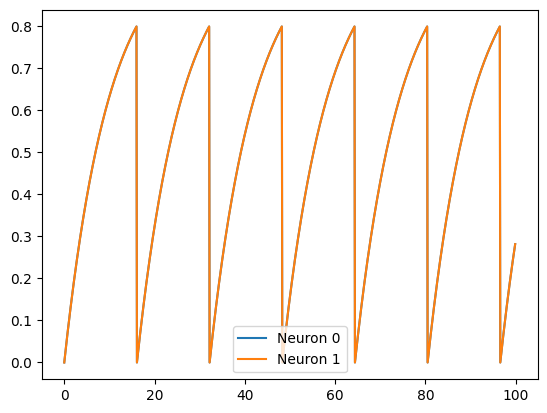

In [4]:
from brian2 import *

start_scope()

# neuron equation
tau = 10*ms

eqs = '''
dv/dt = (1 - v)/tau : 1
'''

# create neurons
G = NeuronGroup(2, eqs, threshold='v>0.8', reset='v=0', method='exact')

# create synapse
S = Synapses(G, G, on_pre='v_post += 0.3')
S.connect(i=0, j=1)

# monitors
M = StateMonitor(G, 'v', record=True)
spike_mon = SpikeMonitor(G)

run(100*ms)

plot(M.t/ms, M.v[0], label="Neuron 0")
plot(M.t/ms, M.v[1], label="Neuron 1")
legend()
show()